## Importing Libraries

In [37]:
import numpy as np
import pandas as pd 
import matplotlib.pyplot as plt

## Importing and preprocessing the dataset

In [38]:
df = pd.read_excel("clickbait_bn.xlsx")
df.dropna(inplace=True)
df.rename(columns={'clickbait': 'label'}, inplace=True)
df['label'] = df['label'].map({0: 'real', 1: 'clickbait'})

In [39]:
print(df.shape)
df.head()

(142, 2)


,thumbnails,label
0,এই ব্যাপারগুলো হতে যাচ্ছে খুব তাড়াতাড়ি,clickbait
1,বদলে যাবে আপনার জীবন এই কাজগুলো করলে,clickbait
2,আমাদের উপরে কি ভয়ংকর বিপদ আসতে যাচ্ছে,clickbait
3,রোজা রাখার ফলে ক্যান্সার সেল ধ্বংস হয়,real
4,কোন দেশে যাব পড়তে,real


## Train-Test Split

In [58]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(df['thumbnails'], df['label'], test_size=0.2, random_state=42, stratify=df['label']) 

In [59]:
y_train.value_counts(normalize=True) # Used Stratify for proportional distribution

label
clickbait    0.548673
real         0.451327
Name: proportion, dtype: float64

In [60]:
y_test.value_counts(normalize=True) # Used Stratify for proportional distribution

label
clickbait    0.551724
real         0.448276
Name: proportion, dtype: float64

In [61]:
print(f"Train : {len(X_train)}, Test : {len(X_test)}")

Train : 113, Test : 29


## Feature Extraction with TF-IDF

In [62]:
import re
def bangla_tokenizer(text):
    # Extract only Bangla words
    words = re.findall(r'[\u0980-\u09FF]+', text)
    return words

In [63]:
from sklearn.feature_extraction.text import TfidfVectorizer
vectorizer = TfidfVectorizer(    
    tokenizer=bangla_tokenizer,
    token_pattern=None,
    lowercase=False,
    ngram_range=(1, 3),
    min_df=2,
    max_df=0.8,
    sublinear_tf=True,
    max_features=10000)
X_train_vec = vectorizer.fit_transform(X_train)
X_test_vec = vectorizer.transform(X_test)

print(f"Feature matrix shape: {X_train_vec.shape}")

Feature matrix shape: (113, 119)


## Training Random Forest Model

In [64]:
from sklearn.ensemble import RandomForestClassifier
classifier = RandomForestClassifier(n_estimators=200, random_state=42, n_jobs=-1)
classifier.fit(X_train_vec, y_train)

RandomForestClassifier(n_estimators=200, n_jobs=-1, random_state=42)

## Evaluation of the test

In [65]:
from sklearn.metrics import classification_report, accuracy_score, confusion_matrix
import seaborn as sns

y_pred = classifier.predict(X_test_vec)
print(f"Accuracy: {accuracy_score(y_test, y_pred)*100:.2f}%")
# Classification Report
print(classification_report(y_test, y_pred))

Accuracy: 68.97%
              precision    recall  f1-score   support

   clickbait       0.82      0.56      0.67        16
        real       0.61      0.85      0.71        13

    accuracy                           0.69        29
   macro avg       0.71      0.70      0.69        29
weighted avg       0.73      0.69      0.69        29



## Plotting confusion Matrix

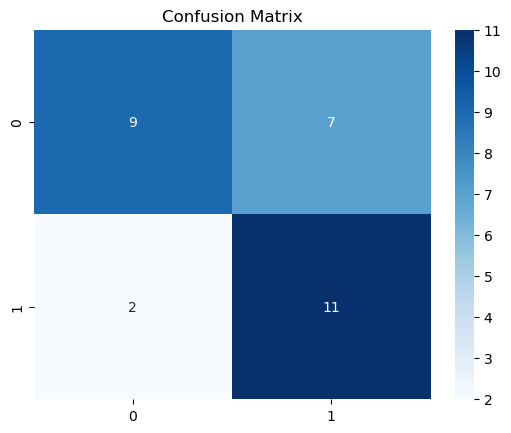

In [66]:
cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.title("Confusion Matrix")
plt.show()